<a href="https://colab.research.google.com/github/aabyyaann/Introduction-to-Machine-Learning-with-Python/blob/main/Chapter8_Wrapping_Up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8 - Wrapping Up

Notebook ini merangkum alur kerja Machine Learning secara menyeluruh berdasarkan buku *Introduction to Machine Learning with Python* karya Andreas C. Müller dan Sarah Guido.

Pada chapter ini, fokus utamanya adalah:
1. Menyusun ulang tahapan proyek machine learning end-to-end.
2. Menunjukkan bagaimana preprocessing, pemilihan model, tuning, dan evaluasi digabungkan dalam satu workflow.
3. Menyajikan contoh pipeline klasifikasi lengkap menggunakan dataset nyata dari scikit-learn.
4. Menutup pembahasan buku dengan ringkasan konsep-konsep penting dari Chapter 1 sampai Chapter 7.

## 1. Tujuan Chapter 8

Chapter ini berfungsi sebagai penutup dari seluruh isi buku. Jika chapter-chapter sebelumnya membahas algoritma, preprocessing, evaluasi, feature engineering, pipeline, dan text processing secara terpisah, maka chapter ini mengajak kita melihat semuanya sebagai satu workflow utuh.

Tujuan utama chapter ini adalah:
- memahami urutan kerja proyek machine learning,
- mengetahui bagaimana memilih model yang sesuai,
- menggunakan pipeline agar proses lebih rapi dan aman,
- mengevaluasi model secara benar,
- serta memahami bahwa machine learning bukan hanya soal memanggil `.fit()`, tetapi soal membangun proses analisis yang terstruktur dari awal sampai akhir.

## 2. Ringkasan Workflow Machine Learning

Secara umum, proyek machine learning dapat diringkas menjadi beberapa tahap utama:

1. **Memahami masalah**
   - Apakah tugasnya klasifikasi, regresi, clustering, atau reduksi dimensi?
   - Apa target yang ingin diprediksi?

2. **Memahami data**
   - Bentuk data seperti apa?
   - Apakah ada missing values?
   - Apakah fitur numerik, kategorikal, atau teks?

3. **Membagi data**
   - Pisahkan data training dan testing agar evaluasi adil.

4. **Preprocessing**
   - Imputasi missing values
   - Scaling
   - Encoding
   - Feature engineering

5. **Membangun model**
   - Memilih algoritma yang cocok
   - Melatih model dengan data training

6. **Evaluasi**
   - Mengukur performa pada data test
   - Menggunakan metrik yang sesuai

7. **Tuning**
   - Mencari hyperparameter terbaik
   - Menggunakan cross-validation

8. **Interpretasi dan deployment**
   - Memahami perilaku model
   - Menyiapkan model untuk digunakan di dunia nyata

## 3. Import Library

Pada notebook ini kita akan menggunakan:
- `pandas` dan `numpy` untuk manipulasi data,
- `matplotlib` untuk visualisasi,
- dataset `breast_cancer` dari scikit-learn,
- `Pipeline` untuk menyusun workflow,
- `GridSearchCV` untuk tuning parameter,
- serta beberapa metrik evaluasi klasifikasi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

print("Library berhasil diimport.")

Library berhasil diimport.


## 4. Memuat Dataset

Sebagai contoh workflow akhir, kita gunakan **Breast Cancer Wisconsin dataset** dari scikit-learn.

Dataset ini berisi fitur-fitur numerik hasil pengukuran sel kanker, dan targetnya adalah:
- **0 = malignant**
- **1 = benign**

Karena ini adalah tugas klasifikasi biner, kita akan membangun model untuk memprediksi apakah suatu sampel termasuk tumor ganas atau jinak.

In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Nama target:", cancer.target_names)
print("Nama fitur (5 pertama):", cancer.feature_names[:5])

Shape X: (569, 30)
Shape y: (569,)
Nama target: ['malignant' 'benign']
Nama fitur (5 pertama): ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [3]:
df = pd.DataFrame(X, columns=cancer.feature_names)
df["target"] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 5. Memahami Struktur Data

Sebelum membangun model, kita perlu memahami:
- jumlah data,
- jumlah fitur,
- distribusi target,
- serta apakah ada indikasi ketidakseimbangan kelas.

Ini penting karena karakteristik data akan memengaruhi pemilihan model dan cara evaluasi.

In [4]:
print("Jumlah sampel:", df.shape[0])
print("Jumlah fitur :", df.shape[1] - 1)
print("\nDistribusi target:")
print(df["target"].value_counts())
print("\nDistribusi target (proporsi):")
print(df["target"].value_counts(normalize=True))

Jumlah sampel: 569
Jumlah fitur : 30

Distribusi target:
target
1    357
0    212
Name: count, dtype: int64

Distribusi target (proporsi):
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


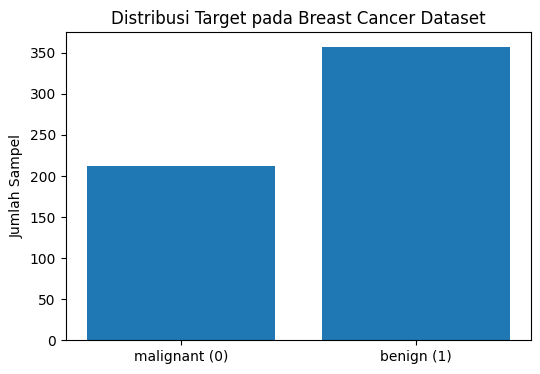

In [5]:
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], target_counts.values)
plt.title("Distribusi Target pada Breast Cancer Dataset")
plt.ylabel("Jumlah Sampel")
plt.show()

## 6. Train-Test Split

Kita membagi data menjadi:
- **training set** → digunakan untuk melatih model,
- **test set** → digunakan untuk evaluasi akhir.

Kita memakai `stratify=y` agar proporsi kelas pada data train dan test tetap seimbang seperti data aslinya.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

Ukuran X_train: (426, 30)
Ukuran X_test : (143, 30)


## 7. Mengapa Perlu Pipeline?

Dalam praktik machine learning, kita sering perlu melakukan beberapa langkah berurutan:
1. scaling fitur,
2. melatih model,
3. tuning hyperparameter.

Daripada menulis langkah-langkah ini secara manual dan berisiko melakukan kesalahan, kita dapat menggunakan **Pipeline**.

Keuntungan pipeline:
- kode lebih rapi,
- preprocessing hanya dipelajari dari data training,
- mengurangi data leakage,
- mudah digabung dengan cross-validation dan grid search.

In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

pipe

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC())])

## 8. Training Model Awal

Sebagai baseline, kita melatih pipeline sederhana:
- `StandardScaler`
- `SVC`

SVM adalah algoritma yang cukup kuat untuk dataset berdimensi sedang seperti dataset kanker payudara ini.

In [8]:
pipe.fit(X_train, y_train)

train_score = pipe.score(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print("Training score:", round(train_score, 3))
print("Test score    :", round(test_score, 3))

Training score: 0.979
Test score    : 0.979


## 9. Interpretasi Baseline Model

Dari skor training dan test, kita dapat mulai menilai:
- apakah model terlalu sederhana,
- apakah model terlalu kompleks,
- atau apakah model sudah cukup generalizable.

Jika skor training jauh lebih tinggi daripada skor test, ada kemungkinan overfitting.
Jika keduanya rendah, bisa jadi model underfitting.
Jika keduanya tinggi dan cukup dekat, model cenderung melakukan generalisasi dengan baik.

## 10. Hyperparameter Tuning dengan Grid Search

Model machine learning biasanya memiliki parameter yang perlu diatur, misalnya pada SVM:
- `C`: mengatur kekuatan regularisasi
- `gamma`: mengatur pengaruh satu data point terhadap boundary
- `kernel`: bentuk fungsi kernel

Agar tidak menebak-nebak, kita gunakan **GridSearchCV** untuk mencoba beberapa kombinasi parameter dan memilih yang terbaik berdasarkan cross-validation.

In [9]:
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": [0.001, 0.01, 0.1, 1],
    "svc__kernel": ["rbf"]
}

grid = GridSearchCV(pipe, param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", round(grid.best_score_, 3))
print("Test score:", round(grid.score(X_test, y_test), 3))

Best parameters: {'svc__C': 10, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
Best cross-validation score: 0.977
Test score: 0.979


## 11. Mengambil Model Terbaik

Setelah grid search selesai, model terbaik dapat diakses melalui `best_estimator_`.

Model inilah yang akan kita gunakan untuk evaluasi akhir, karena ia sudah melalui proses pencarian hyperparameter terbaik.

In [10]:
best_model = grid.best_estimator_
best_model

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(C=10, gamma=0.001))])

In [11]:
y_pred = best_model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))

Accuracy: 0.979


## 12. Confusion Matrix

Akurasi saja sering belum cukup. Kita juga ingin tahu:
- berapa banyak prediksi benar untuk masing-masing kelas,
- apakah model sering salah memprediksi malignant sebagai benign,
- atau sebaliknya.

Untuk itu kita gunakan **confusion matrix**.

In [12]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[51,  2],
       [ 1, 89]])

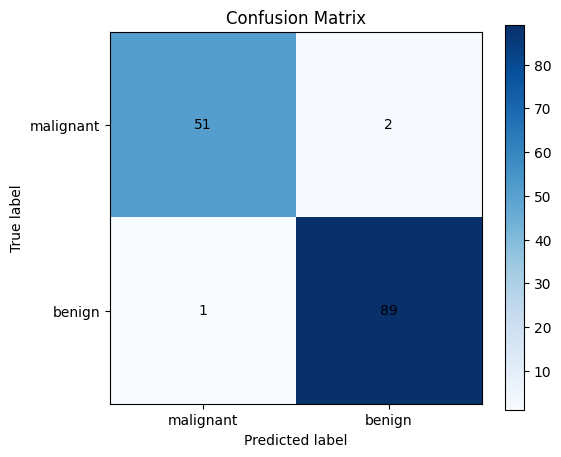

In [13]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], cancer.target_names)
plt.yticks([0, 1], cancer.target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 13. Classification Report

Selain confusion matrix, kita juga dapat melihat metrik per kelas:
- **precision**
- **recall**
- **f1-score**

Metrik ini sangat penting, terutama ketika salah satu jenis kesalahan lebih berbahaya daripada yang lain. Pada kasus kanker, kesalahan memprediksi tumor ganas sebagai jinak tentu sangat berisiko.

In [14]:
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        53
      benign       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



## 14. ROC Curve dan AUC

Untuk klasifikasi biner, kita juga bisa mengevaluasi model menggunakan:
- **ROC Curve**
- **AUC (Area Under the Curve)**

ROC menunjukkan trade-off antara:
- **True Positive Rate**
- **False Positive Rate**

Semakin besar AUC, semakin baik model membedakan dua kelas.

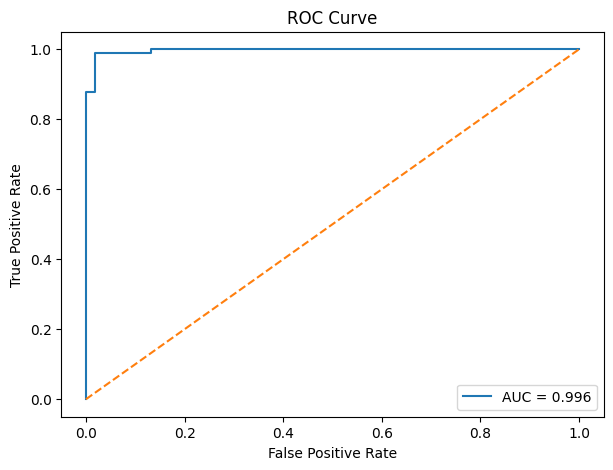

In [15]:
decision_scores = best_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, decision_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## 15. Cross-Validation sebagai Estimasi yang Lebih Stabil

Train-test split hanya memberikan satu pembagian data. Kadang hasilnya terlalu bergantung pada split tersebut.

Untuk mendapatkan estimasi performa yang lebih stabil, kita bisa memakai **cross-validation**. Pada metode ini, data dibagi menjadi beberapa fold, lalu model dilatih dan diuji berkali-kali.

In [16]:
scores = cross_val_score(best_model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV score:", round(scores.mean(), 3))
print("Std CV score :", round(scores.std(), 3))

Cross-validation scores: [0.95614035 0.97368421 0.97368421 0.96491228 0.98230088]
Mean CV score: 0.97
Std CV score : 0.009


## 16. Menyusun Ringkasan Hasil Eksperimen

Supaya hasil lebih mudah dibaca, kita bisa merangkum performa model ke dalam sebuah tabel sederhana.

In [17]:
summary = pd.DataFrame({
    "Metric": [
        "Training Score (baseline pipeline)",
        "Test Score (baseline pipeline)",
        "Best CV Score (GridSearch)",
        "Test Score (best model)",
        "Mean CV Score (best model)"
    ],
    "Value": [
        train_score,
        test_score,
        grid.best_score_,
        accuracy_score(y_test, y_pred),
        scores.mean()
    ]
})

summary["Value"] = summary["Value"].round(4)
summary

,Metric,Value
0,Training Score (baseline pipeline),0.9789
1,Test Score (baseline pipeline),0.9790
2,Best CV Score (GridSearch),0.9765
3,Test Score (best model),0.9790
4,Mean CV Score (best model),0.9701


## 17. Apa yang Dipelajari dari Workflow Ini?

Dari notebook ini, kita bisa melihat bahwa proyek machine learning yang baik bukan hanya soal memilih algoritma, tetapi juga soal menyusun alur kerja yang benar:

1. **Memahami data lebih dulu**
   - Kenali bentuk data, fitur, target, dan distribusi kelas.

2. **Pisahkan data train dan test**
   - Evaluasi harus dilakukan pada data yang tidak pernah dilihat model saat training.

3. **Gunakan preprocessing yang sesuai**
   - Pada data numerik, scaling sering kali penting, terutama untuk model seperti SVM dan KNN.

4. **Gunakan pipeline**
   - Pipeline menjaga urutan preprocessing dan modeling tetap konsisten.
   - Pipeline juga membantu menghindari data leakage.

5. **Lakukan tuning hyperparameter**
   - Model yang baik jarang muncul dari parameter default.
   - GridSearchCV membantu memilih kombinasi parameter terbaik secara sistematis.

6. **Gunakan evaluasi yang tepat**
   - Jangan hanya bergantung pada satu angka seperti accuracy.
   - Gunakan confusion matrix, classification report, ROC curve, dan cross-validation.

## 18. Hubungan Chapter 8 dengan Chapter Sebelumnya

Chapter 8 sebenarnya menyatukan seluruh isi buku:

- **Chapter 1** mengenalkan machine learning dan workflow dasar.
- **Chapter 2** membahas supervised learning seperti KNN, linear models, trees, dan ensembles.
- **Chapter 3** membahas unsupervised learning, clustering, PCA, dan preprocessing.
- **Chapter 4** membahas representasi data dan feature engineering.
- **Chapter 5** membahas evaluasi model, cross-validation, metrik, dan grid search.
- **Chapter 6** membahas pipeline dan workflow yang lebih rapi.
- **Chapter 7** membahas pengolahan text data dengan bag-of-words, TF-IDF, dan model klasifikasi teks.
- **Chapter 8** menutup semuanya dengan menekankan bahwa machine learning adalah proses end-to-end, bukan langkah yang berdiri sendiri.

## 19. Kesimpulan Chapter 8

Chapter 8 menegaskan bahwa keberhasilan machine learning tidak hanya bergantung pada algoritma yang canggih, tetapi juga pada bagaimana kita membangun workflow secara disiplin.

Hal-hal terpenting yang perlu dibawa dari buku ini adalah:

- selalu mulai dari pemahaman masalah dan data,
- pisahkan data train dan test dengan benar,
- gunakan preprocessing yang sesuai,
- manfaatkan pipeline untuk menjaga workflow tetap aman,
- evaluasi model dengan metrik yang relevan,
- lakukan tuning hyperparameter secara sistematis,
- dan pilih model berdasarkan kemampuan generalisasi, bukan hanya performa pada training set.

Dengan memahami alur ini, kita tidak hanya bisa menjalankan model, tetapi juga bisa membangun proyek machine learning yang lebih rapi, valid, dan siap digunakan pada kasus nyata.

In [19]:
print("Notebook Chapter 8 selesai dijalankan.")


Notebook Chapter 8 selesai dijalankan.
